# Libraries

In [87]:
import matplotlib.pyplot as plt
import pandas as pd


# Aux functions

In [88]:
from collections.abc import Sequence


def check_nans(df: pd.DataFrame, columns: Sequence[str],
                show_percent: bool = True,  # noqa: FBT001, FBT002
                sort: bool = True) -> pd.DataFrame:  # noqa: FBT001, FBT002
    """
    Quick check for NaNs in dataframe columns.
    Args:
        df: pandas.DataFrame
        columns: list of column names to check (None -> all columns)
        show_percent: include missing percentage column
        sort: sort result by missing_count desc
    Returns:
        pandas.DataFrame with index = column and columns:
            missing_count, missing_pct (optional), non_missing_count, dtype
    """  # noqa: DOC201

    if columns is None:  # type: ignore  # noqa: PGH003
        columns = list(df.columns)  # two spaces before comment
    total = len(df)  # two spaces before comment
    rows = []
    for col in columns:
        ser = df[col]  # two spaces before comment
        missing = int(ser.isna().sum())  # two spaces before comment

        rows.append({  # type: ignore  # noqa: PGH003
            "column": col,
            "missing_count": missing,
            "missing_pct": (missing / total) * 100 if total > 0 else 0.0,
            "non_missing_count": total - missing,
            "dtype": str(ser.dtype)
        })
    out = pd.DataFrame(rows).set_index("column")
    if not show_percent:
        out = out.drop(columns="missing_pct")
    if sort:
        out = out.sort_values("missing_count", ascending=False)
    return out


In [89]:
def plot_value_counts(df: pd.DataFrame, column_name: str, xlabel: str | None = None, ylabel: str = "Frequency") -> None:  # type: ignore  # noqa: E501, PGH003
    """
    Plots a bar chart of value counts for a specified column in a DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        column_name (str): The column name to plot value counts for.
        xlabel (str | None, optional): Label for the x-axis. Defaults to the column name
        ylabel (str, optional): Label for the y-axis. Defaults to 'Frequency'.
    """
    counts = df[column_name].value_counts().sort_index()

    plt.figure(figsize=(10, 6))  # type: ignore  # noqa: PGH003
    bars = counts.plot(kind="bar", edgecolor="black")

    # Add value labels on top of each bar
    for container in bars.containers:
        bars.bar_label(container, fmt="%d")  # type: ignore  # noqa: PGH003

    plt.xlabel(xlabel or column_name)  # type: ignore  # noqa: PGH003
    plt.ylabel(ylabel)  # type: ignore  # noqa: PGH003
    plt.xticks(rotation=0)  # type: ignore  # noqa: PGH003
    plt.grid(axis="y", alpha=0.3)  # type: ignore  # noqa: PGH003
    plt.tight_layout()
    plt.show()  # type: ignore  # noqa: PGH003


# Data Loading

In [90]:
df = pd.read_csv("../dataset/merged_data.csv", sep=";") # type: ignore

df.head()

,SEQN,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ151,ALQ170,BMDSTATS,...,PAD820,PAD680,SMQ020,SMQ040,SMD641,SMD650,SMD100MN,SMQ621,SMD630,SMAQUEX2
0,130378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,...,45.0,360.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1
1,130379,1.0,2.0,3.0,0.0,NaN,NaN,2.0,NaN,1,...,45.0,480.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1
2,130380,1.0,10.0,1.0,0.0,NaN,NaN,2.0,NaN,1,...,NaN,240.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1
3,130386,1.0,4.0,2.0,10.0,0.0,10.0,2.0,0.0,1,...,30.0,180.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1
4,130387,1.0,0.0,NaN,NaN,NaN,NaN,2.0,NaN,1,...,NaN,1200.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1


## Feature filtering

In [91]:
REQUIRED_COLUMNS = [
    # Identifier
    "SEQN",

    # Demographics
    "RIDAGEYR",     # Age
    "RIAGENDR",     # Gender
    "RIDRETH3",     # Race/Ethnicity

    # Socioeconomic Status
    "DMDEDUC2",     # Education level
    "INDFMPIR",     # Income-to-poverty ratio
    "DMDHHSIZ",     # Household size
    "DMDMARTZ",     # Marital status

    # Body Measurements
    "BMXBMI",       # BMI
    "BMXWAIST",     # Waist circumference
    "BMXWT",        # Weight
    "BMXHT",        # Height

    # Blood Pressure (3 readings each)
    "BPXOSY1", "BPXOSY2", "BPXOSY3",  # Systolic readings
    "BPXODI1", "BPXODI2", "BPXODI3",  # Diastolic readings

    # Smoking
    "SMQ020",       # Ever smoked at least 100 cigarettes
    "SMQ040",       # Current smoking status
    "SMD650",       # Cigarettes per day

    # Alcohol
    "ALQ121",       # Drinking frequency
    "ALQ130",       # Drinks per day
    "ALQ170",       # Binge drinking episodes

    # Physical Activity
    "PAD790Q",      # Moderate activity frequency
    "PAD790U",      # Moderate activity unit (D/W/M/Y)
    "PAD800",       # Moderate activity minutes per session
    "PAD810Q",      # Vigorous activity frequency
    "PAD810U",      # Vigorous activity unit (D/W/M/Y)
    "PAD820",       # Vigorous activity minutes per session
    "PAD680",       # Sedentary minutes per day

    # Survey Weights
    "WTMEC2YR",

    # Target Variable
    "DIQ010"        # Diabetes diagnosis
]

In [92]:
df = df[REQUIRED_COLUMNS].copy()

Feature groups

In [93]:
# Demographics
DEMO_COLUMNS = {
    "CATEGORICAL": [
        "RIAGENDR",  # Gender
        "RIDRETH3",     # Race/Ethnicity
        "DMDEDUC2",     # Education level
        "DMDMARTZ"      # Marital status
    ],
    "CONTINUOUS": [
        "RIDAGEYR",     # Age
        "INDFMPIR",     # Income-to-poverty ratio
        "DMDHHSIZ"    # Household size
]}

# Body Measurements
BMX_COLUMNS = [
    "BMXBMI",       # BMI
    "BMXWAIST",     # Waist circumference
    "BMXWT",        # Weight
    "BMXHT"         # Height
]

# Blood Pressure (3 readings each)
BP_COLUMNS = [
    "BPXOSY1", "BPXOSY2", "BPXOSY3",  # Systolic readings
    "BPXODI1", "BPXODI2", "BPXODI3"   # Diastolic readings
]

# Smoking
SMQ_COLUMNS = [
    "SMQ020",       # Ever smoked at least 100 cigarettes
    "SMQ040",      # Current smoking status
    "SMD650"       # Cigarettes per day
]

# Alcohol
ALQ_COLUMNS = [
    "ALQ121",       # Drinking frequency
    "ALQ130",       # Drinks per day
    "ALQ170"        # Binge drinking episodes
]

# Physical Activity
PAD_COLUMNS = [
    "PAD790Q",      # Moderate activity frequency
    "PAD790U",      # Moderate activity unit (D/W/M/Y)
    "PAD800",       # Moderate activity minutes per session
    "PAD810Q",      # Vigorous activity frequency
    "PAD810U",      # Vigorous activity unit (D/W/M/Y)
    "PAD820",       # Vigorous activity minutes per session
    "PAD680"        # Sedentary minutes per day
]

# Feature validation check

## Demographics

Categorical:

* RIAGENDR
* RIDRETH3
* DMDEDUC2 #Adults+20
* DMDMARTZ

Numerical:

* RIDAGEYR
* INDFMPIR
* DMDHHZIS

### Numerical

In [94]:
df[DEMO_COLUMNS["CONTINUOUS"]].describe()

,RIDAGEYR,INDFMPIR,DMDHHSIZ
count,6337.000000,5506.000000,6337.000000
mean,52.325548,2.893249,2.624586
std,18.280888,1.660074,1.485297
min,18.000000,0.000000,1.000000
25%,37.000000,1.380000,2.000000
50%,56.000000,2.790000,2.000000
75%,67.000000,4.940000,4.000000
max,80.000000,5.000000,7.000000


In [95]:
df[DEMO_COLUMNS["CONTINUOUS"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   RIDAGEYR  6337 non-null   int64  
 1   INDFMPIR  5506 non-null   float64
 2   DMDHHSIZ  6337 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 148.7 KB


In [96]:
df[DEMO_COLUMNS["CONTINUOUS"][1]].unique()

array([5.  , 1.41, 1.33, 1.32, 0.81, 2.16, 0.93, 3.04, 1.1 , 4.82, 4.48,
       1.67, 0.91, 3.36, 4.42, 3.22, 4.37, 1.02, 3.14, 0.05, 0.11,  nan,
       0.2 , 2.64, 3.82, 1.91, 0.88, 3.43, 1.19, 0.67, 1.09, 4.22, 0.65,
       4.36, 3.47, 1.65, 2.33, 1.08, 1.27, 2.73, 0.79, 2.98, 1.52, 0.96,
       2.06, 3.97, 4.06, 3.44, 2.43, 0.73, 1.64, 3.02, 1.46, 4.31, 1.23,
       4.71, 3.58, 0.86, 0.92, 3.57, 0.51, 4.62, 0.07, 1.94, 1.2 , 0.18,
       1.66, 3.24, 2.61, 1.72, 0.69, 4.08, 2.41, 2.17, 0.57, 4.54, 4.17,
       2.31, 4.68, 0.61, 0.87, 3.7 , 3.  , 2.52, 2.82, 0.23, 0.39, 1.04,
       3.68, 1.97, 2.29, 1.01, 0.77, 0.85, 0.89, 3.28, 1.35, 1.61, 1.84,
       2.21, 1.37, 1.4 , 2.13, 3.18, 3.09, 2.87, 1.44, 3.88, 1.51, 1.75,
       1.85, 0.24, 2.58, 1.26, 4.57, 1.81, 0.  , 1.03, 4.32, 1.62, 1.48,
       0.75, 4.88, 1.39, 1.69, 3.45, 3.11, 0.66, 2.8 , 3.3 , 3.55, 4.23,
       2.25, 1.13, 4.83, 4.92, 0.94, 2.94, 2.54, 2.88, 3.69, 2.5 , 2.15,
       4.69, 1.16, 1.12, 0.72, 2.81, 0.55, 0.04, 2.

In [97]:
# Let's investigate the INDFMPIR values more carefully
print(f"Min value: {df[DEMO_COLUMNS['CONTINUOUS'][1]].min()}")
print(f"Max value: {df[DEMO_COLUMNS['CONTINUOUS'][1]].max()}")
print(f"Values below 0.1: {df[df[DEMO_COLUMNS['CONTINUOUS'][1]] < 0.1][DEMO_COLUMNS['CONTINUOUS'][1]].values}")
print(f"\nNumber of values below 0.1: {(df[DEMO_COLUMNS['CONTINUOUS'][1]] < 0.1).sum()}")
print(f"Number of missing values: {df[DEMO_COLUMNS['CONTINUOUS'][1]].isna().sum()}")

Min value: 0.0
Max value: 5.0
Values below 0.1: [0.05 0.07 0.   0.   0.   0.04 0.03 0.   0.   0.   0.   0.04 0.   0.
 0.   0.02 0.06 0.   0.   0.02 0.   0.08 0.   0.   0.03 0.   0.   0.03
 0.06 0.03 0.02 0.01 0.   0.01 0.   0.07 0.   0.   0.   0.08 0.02 0.07
 0.03 0.02 0.   0.   0.   0.   0.   0.   0.09 0.05 0.   0.   0.02 0.07
 0.04 0.   0.09 0.07 0.01 0.   0.05 0.09 0.04 0.   0.05 0.   0.04 0.04
 0.05 0.07 0.   0.03 0.02 0.09 0.05 0.05 0.   0.   0.   0.05 0.06 0.
 0.03 0.08 0.   0.04 0.   0.   0.02 0.05 0.02 0.   0.   0.04 0.03 0.02
 0.06 0.04 0.08 0.03 0.   0.04 0.   0.   0.   0.   0.06 0.03 0.03 0.02
 0.05 0.   0.05 0.01 0.   0.01 0.   0.   0.05 0.   0.   0.  ]

Number of values below 0.1: 124
Number of missing values: 831


Nan checks

In [98]:
check_nans(df, DEMO_COLUMNS["CONTINUOUS"])

,missing_count,missing_pct,non_missing_count,dtype
column,,,,
INDFMPIR,831,13.113461,5506,float64
RIDAGEYR,0,0.000000,6337,int64
DMDHHSIZ,0,0.000000,6337,int64


### Categorical

In [99]:
df[DEMO_COLUMNS["CATEGORICAL"]].describe()

,RIAGENDR,RIDRETH3,DMDEDUC2,DMDMARTZ
count,6337.000000,6337.000000,6064.000000,6063.000000
mean,1.548998,3.309768,3.839380,1.725383
std,0.497633,1.400246,1.144338,2.500998
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,3.000000,3.000000,1.000000
50%,2.000000,3.000000,4.000000,1.000000
75%,2.000000,3.000000,5.000000,2.000000
max,2.000000,7.000000,9.000000,99.000000


In [100]:
# RIAGENDR
print(f' Gender values: \n {df[DEMO_COLUMNS["CATEGORICAL"][0]].value_counts()}\n')
print(f' Ethnicity values: \n {df[DEMO_COLUMNS["CATEGORICAL"][1]].value_counts()}\n')
print(f' Education level values: \n {df[DEMO_COLUMNS["CATEGORICAL"][2]].value_counts()}\n')
print(f' Marital status values: \n {df[DEMO_COLUMNS["CATEGORICAL"][3]].value_counts()}\n')

 Gender values: 
 RIAGENDR
2    3479
1    2858
Name: count, dtype: int64

 Ethnicity values: 
 RIDRETH3
3    3684
4     791
2     647
1     448
7     414
6     353
Name: count, dtype: int64

 Education level values: 
 DMDEDUC2
5.0    2143
4.0    1846
3.0    1297
2.0     482
1.0     292
9.0       4
Name: count, dtype: int64

 Marital status values: 
 DMDMARTZ
1.0     3277
2.0     1536
3.0     1246
99.0       3
77.0       1
Name: count, dtype: int64



Check Nans

In [101]:
check_nans(df, DEMO_COLUMNS["CATEGORICAL"])

,missing_count,missing_pct,non_missing_count,dtype
column,,,,
DMDMARTZ,274,4.323813,6063,float64
DMDEDUC2,273,4.308032,6064,float64
RIDRETH3,0,0.000000,6337,int64
RIAGENDR,0,0.000000,6337,int64


## Body Measurements

Continuous features:
 
* BMXBMI
* BMXWAIST
* BMXWT
* BMXHT  


In [102]:
df[BMX_COLUMNS].describe()

,BMXBMI,BMXWAIST,BMXWT,BMXHT
count,6235.000000,6019.000000,6248.000000,6262.000000
mean,29.659326,100.455225,82.878132,166.954982
std,7.395826,17.171398,22.464318,10.051394
min,11.100000,59.600000,27.900000,133.000000
25%,24.500000,88.100000,67.000000,159.700000
50%,28.300000,99.000000,79.500000,166.600000
75%,33.400000,111.000000,95.000000,174.200000
max,74.800000,187.000000,248.200000,200.700000


In [103]:
df[df["BMXWT"] < 45]  # noqa: PLR2004

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,DMDHHSIZ,DMDMARTZ,BMXBMI,BMXWAIST,...,ALQ170,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680,WTMEC2YR,DIQ010
59,130478,69,2,3,5.0,NaN,2,1.0,16.7,66.0,...,NaN,4.0,W,30.0,0.0,NaN,NaN,240.0,13220.966050,2
282,130911,67,2,3,5.0,2.81,2,1.0,18.4,64.6,...,NaN,1.0,D,30.0,0.0,NaN,NaN,240.0,16311.631060,2
743,131773,18,2,2,NaN,1.23,5,NaN,18.2,67.2,...,NaN,3.0,W,30.0,3.0,W,30.0,540.0,23343.268360,2
1160,132555,72,2,3,4.0,0.56,1,3.0,18.1,75.2,...,NaN,1.0,W,10.0,0.0,NaN,NaN,480.0,22401.176040,1
1319,132868,69,2,3,3.0,1.46,7,2.0,19.1,71.4,...,NaN,0.0,NaN,NaN,0.0,NaN,NaN,300.0,27233.865710,2
1450,133091,80,2,3,5.0,4.73,1,2.0,19.9,NaN,...,NaN,0.0,NaN,NaN,0.0,NaN,NaN,120.0,21709.827130,2
1530,133231,19,2,3,NaN,5.00,4,NaN,17.6,67.2,...,NaN,1.0,D,300.0,0.0,NaN,NaN,360.0,39417.666650,2
1758,133683,56,2,6,3.0,0.69,1,2.0,19.8,77.0,...,NaN,1.0,D,30.0,2.0,W,60.0,60.0,18618.745360,2
1788,133739,19,2,6,NaN,5.00,3,NaN,16.1,59.6,...,1.0,2.0,W,30.0,1.0,W,60.0,360.0,65060.277890,2
1852,133864,80,2,3,5.0,NaN,1,2.0,NaN,79.9,...,0.0,2.0,W,40.0,0.0,NaN,NaN,360.0,30410.006780,2


Check Nans

In [104]:
check_nans(df, BMX_COLUMNS)

,missing_count,missing_pct,non_missing_count,dtype
column,,,,
BMXWAIST,318,5.018147,6019,float64
BMXBMI,102,1.609594,6235,float64
BMXWT,89,1.404450,6248,float64
BMXHT,75,1.183525,6262,float64


## Blood Pressure

Continuous features:

* BPXOSY1 - Systolic reading 1
* BPXOSY2 - Systolic reading 2
* BPXOSY3 - Systolic reading 3
* BPXODI1 - Diastolic reading 1
* BPXODI2 - Diastolic reading 2
* BPXODI3 - Diastolic reading 3

In [105]:
df[BP_COLUMNS].describe()

,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3
count,6123.000000,6116.000000,6101.000000,6123.000000,6116.000000,6101.000000
mean,122.561653,122.412852,122.210293,74.974686,74.311478,73.956564
std,18.451812,18.398605,18.294804,11.416594,11.327270,11.234618
min,73.000000,65.000000,62.000000,36.000000,32.000000,26.000000
25%,110.000000,110.000000,110.000000,67.000000,67.000000,66.000000
50%,120.000000,120.000000,120.000000,74.000000,74.000000,73.000000
75%,133.000000,132.000000,132.000000,82.000000,81.000000,81.000000
max,232.000000,233.000000,232.000000,142.000000,139.000000,136.000000


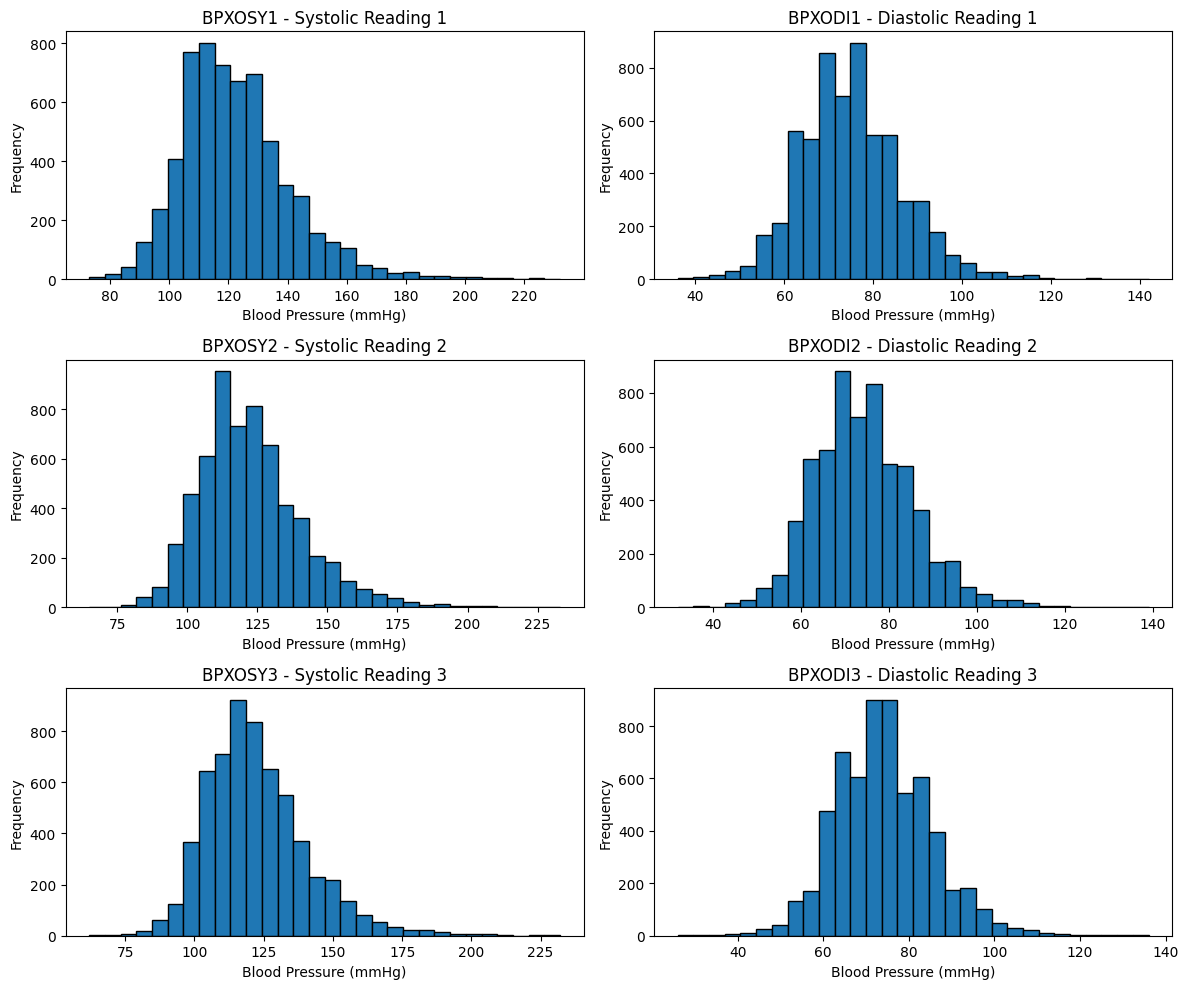

In [106]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10)) # type: ignore

# Plot systolic readings in the first column
axes[0, 0].hist(df["BPXOSY1"].dropna(), bins=30, edgecolor="black")
axes[0, 0].set_title("BPXOSY1 - Systolic Reading 1")
axes[0, 0].set_xlabel("Blood Pressure (mmHg)")
axes[0, 0].set_ylabel("Frequency")

axes[1, 0].hist(df["BPXOSY2"].dropna(), bins=30, edgecolor="black")
axes[1, 0].set_title("BPXOSY2 - Systolic Reading 2")
axes[1, 0].set_xlabel("Blood Pressure (mmHg)")
axes[1, 0].set_ylabel("Frequency")

axes[2, 0].hist(df["BPXOSY3"].dropna(), bins=30, edgecolor="black")
axes[2, 0].set_title("BPXOSY3 - Systolic Reading 3")
axes[2, 0].set_xlabel("Blood Pressure (mmHg)")
axes[2, 0].set_ylabel("Frequency")

# Plot diastolic readings in the second column
axes[0, 1].hist(df["BPXODI1"].dropna(), bins=30, edgecolor="black")
axes[0, 1].set_title("BPXODI1 - Diastolic Reading 1")
axes[0, 1].set_xlabel("Blood Pressure (mmHg)")
axes[0, 1].set_ylabel("Frequency")

axes[1, 1].hist(df["BPXODI2"].dropna(), bins=30, edgecolor="black")
axes[1, 1].set_title("BPXODI2 - Diastolic Reading 2")
axes[1, 1].set_xlabel("Blood Pressure (mmHg)")
axes[1, 1].set_ylabel("Frequency")

axes[2, 1].hist(df["BPXODI3"].dropna(), bins=30, edgecolor="black")
axes[2, 1].set_title("BPXODI3 - Diastolic Reading 3")
axes[2, 1].set_xlabel("Blood Pressure (mmHg)")
axes[2, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show() # type: ignore

In [107]:
check_nans(df, BP_COLUMNS)

,missing_count,missing_pct,non_missing_count,dtype
column,,,,
BPXODI3,236,3.724160,6101,float64
BPXOSY3,236,3.724160,6101,float64
BPXODI2,221,3.487455,6116,float64
BPXOSY2,221,3.487455,6116,float64
BPXOSY1,214,3.376992,6123,float64
BPXODI1,214,3.376992,6123,float64


In [108]:
# Check rows with missing values in all 3 systolic pressure measures
systolic_cols = ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
all_systolic_missing = df[systolic_cols].isna().all(axis=1).sum()

print(f"Number of rows with missing values in ALL systolic pressure measures: {all_systolic_missing}")
print(f"Percentage: {(all_systolic_missing / len(df)) * 100:.2f}%")

Number of rows with missing values in ALL systolic pressure measures: 214
Percentage: 3.38%


In [109]:
# Check rows with missing values in all 3 diastolic pressure measures
diastolic_cols = ["BPXODI1", "BPXODI2", "BPXODI3"]
all_diastolic_missing = df[diastolic_cols].isna().all(axis=1).sum()

print(f"Number of rows with missing values in ALL diastolic pressure measures: {all_diastolic_missing}")
print(f"Percentage: {(all_diastolic_missing / len(df)) * 100:.2f}%")

Number of rows with missing values in ALL diastolic pressure measures: 214
Percentage: 3.38%


In [110]:
# Check rows with missing values in ALL blood pressure measures (both systolic and diastolic)
all_bp_missing = df[BP_COLUMNS].isna().all(axis=1).sum()

print(f"Number of rows with missing values in ALL blood pressure measures: {all_bp_missing}")
print(f"Percentage: {(all_bp_missing / len(df)) * 100:.2f}%")

Number of rows with missing values in ALL blood pressure measures: 214
Percentage: 3.38%


## Smoking features

Continuous/Categorical features:

* SMQ020 - Ever smoked more than 100 cigarretes
* SMQ040 - Current smoking status [Categorical: 3 levels]
* SMD650 - Cigarettes per day [Continuous]


### Ever smoked 100 cigarretes [SMQ020]

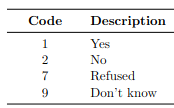

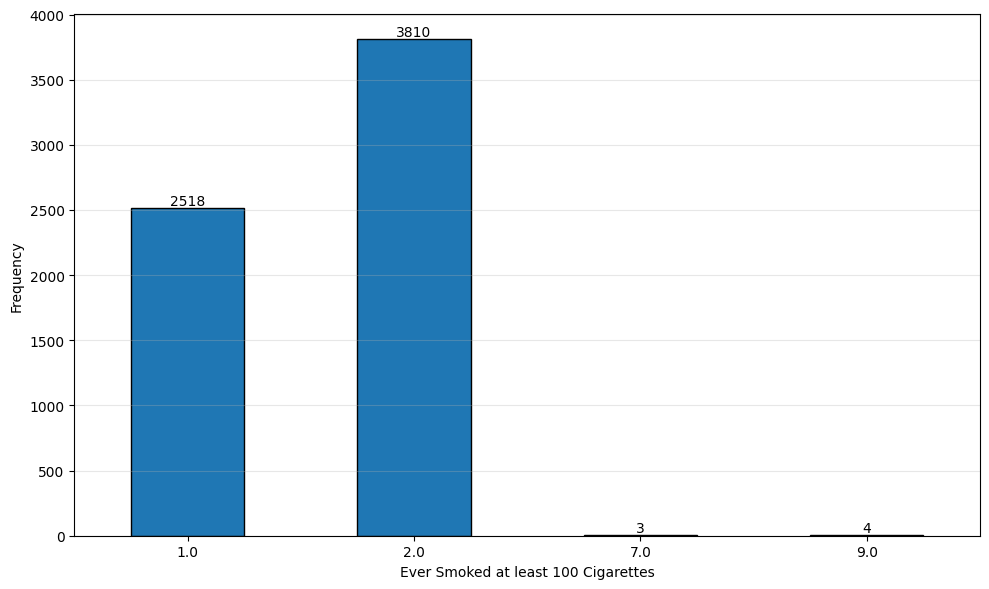

In [111]:
plot_value_counts(df, "SMQ020", xlabel="Ever Smoked at least 100 Cigarettes")

### Smoking status [SMQ040]:

* 1 = Every day
* 2 = Some days
* 3 = not at all

In [112]:
df["SMQ040"].describe()

count    2518.000000
mean        2.339952
std         0.901815
min         1.000000
25%         1.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: SMQ040, dtype: float64

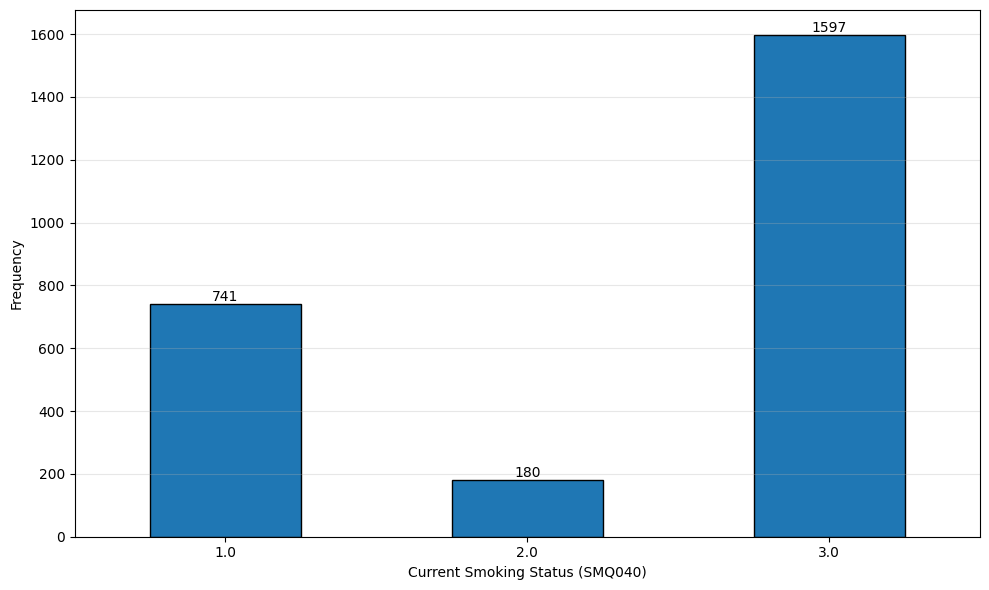

In [113]:
plot_value_counts(df, "SMQ040", xlabel="Current Smoking Status (SMQ040)")

### Cigarretes per day [SMD650]

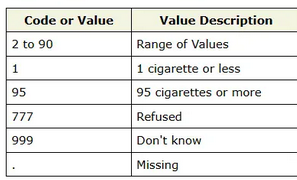

In [114]:
df["SMD650"].describe()

count    912.000000
mean      18.188596
std       80.499562
min        1.000000
25%        5.000000
50%       10.000000
75%       20.000000
max      999.000000
Name: SMD650, dtype: float64

In [115]:
smd650_col = df["SMD650"]

count_eq_1 = (smd650_col == 1).sum()
count_1_to_95 = ((smd650_col > 1) & (smd650_col <= 95)).sum()  # noqa: PLR2004
count_95_to_777 = ((smd650_col > 95) & (smd650_col < 777)).sum()  # noqa: PLR2004
count_777 = (smd650_col == 777).sum()  # noqa: PLR2004
count_999 = (smd650_col == 999).sum()  # noqa: PLR2004

print(f"Values equal to 1: {count_eq_1}")  # noqa: T201
print(f"Values between 1 and 95: {count_1_to_95}")  # noqa: T201
print(f"Values between 95 and 777: {count_95_to_777}")  # noqa: T201
print(f"Values equal to 777: {count_777}")  # noqa: T201
print(f"Values equal to 999: {count_999}")  # noqa: T201


Values equal to 1: 72
Values between 1 and 95: 834
Values between 95 and 777: 0
Values equal to 777: 0
Values equal to 999: 6


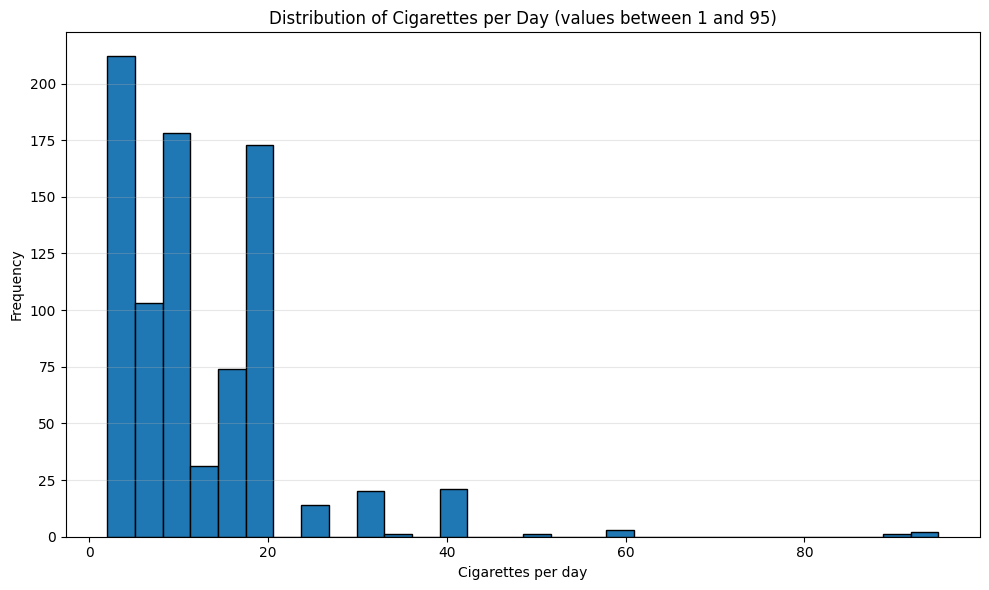

In [116]:
MAX_CIGARETTES = 95

plt.figure(figsize=(10, 6)) # type: ignore
plt.hist(df[(df["SMD650"] > 1) & (df["SMD650"] <= MAX_CIGARETTES)]["SMD650"].dropna(), bins=30, edgecolor="black") # type: ignore
plt.xlabel("Cigarettes per day") # type: ignore
plt.ylabel("Frequency") # type: ignore
plt.title(f"Distribution of Cigarettes per Day (values between 1 and {MAX_CIGARETTES})") # type: ignore
plt.grid(axis="y", alpha=0.3) # type: ignore
plt.tight_layout()
plt.show() # type: ignore

In [117]:
check_nans(df, SMQ_COLUMNS)

,missing_count,missing_pct,non_missing_count,dtype
column,,,,
SMD650,5425,85.608332,912,float64
SMQ040,3819,60.265110,2518,float64
SMQ020,2,0.031561,6335,float64


## Alcohol consumption
Continuous/Categorical features:

* ALQ121 - Drinking frequency
* ALQ130 - Drinks per day
* ALQ170 - Binge drinking episodes on the last month


**ALQ121** -> Think how to group together some categories

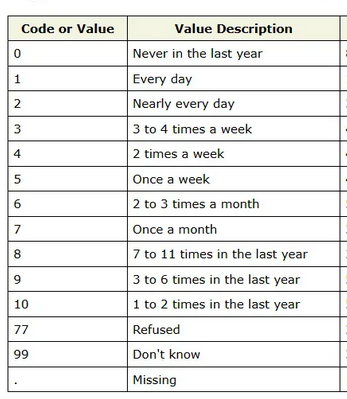

**ALQ130** 

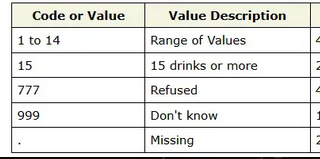

**ALQ170**

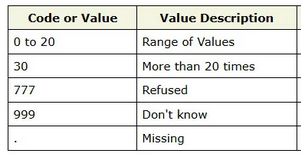

In [118]:
for col in ALQ_COLUMNS:
    print(f"Value counts for {col}:")  # noqa: T201
    print(df[col].value_counts(dropna=False))  # noqa: T201
    print("-" * 40)  # noqa: T201

Value counts for ALQ121:
ALQ121
NaN     1415
0.0      836
6.0      574
10.0     542
9.0      517
4.0      483
3.0      458
5.0      420
7.0      362
2.0      301
8.0      261
1.0      163
99.0       3
77.0       2
Name: count, dtype: int64
----------------------------------------
Value counts for ALQ130:
ALQ130
NaN      2268
1.0      1345
2.0      1312
3.0       599
4.0       251
5.0       216
6.0       141
12.0       55
8.0        42
10.0       31
15.0       20
9.0        19
7.0        17
999.0      10
777.0       4
11.0        4
14.0        2
13.0        1
Name: count, dtype: int64
----------------------------------------
Value counts for ALQ170:
ALQ170
NaN      3979
0.0      1129
1.0       465
2.0       273
3.0       142
4.0        91
5.0        65
30.0       43
6.0        31
20.0       31
8.0        29
10.0       13
7.0        11
15.0       10
9.0         9
12.0        4
18.0        3
777.0       3
999.0       3
13.0        1
17.0        1
14.0        1
Name: count, dtype: int64
--

In [119]:
check_nans(df, ALQ_COLUMNS)

,missing_count,missing_pct,non_missing_count,dtype
column,,,,
ALQ170,3979,62.789964,2358,float64
ALQ130,2268,35.789806,4069,float64
ALQ121,1415,22.329178,4922,float64


## PAD COLUMNS

## Physical Activity Features

Continuous/Categorical features:

* **PAD790Q** - Moderate activity frequency
* **PAD790U** - Moderate activity unit (D/W/M/Y) [Categorical]
* **PAD800** - Moderate activity minutes per session
* **PAD810Q** - Vigorous activity frequency
* **PAD810U** - Vigorous activity unit (D/W/M/Y) [Categorical]
* **PAD820** - Vigorous activity minutes per session
* **PAD680** - Sedentary minutes per day

In [120]:
check_nans(df, PAD_COLUMNS)

,missing_count,missing_pct,non_missing_count,dtype
column,,,,
PAD810U,3461,54.615749,2876,object
PAD820,3460,54.599968,2877,float64
PAD790U,1306,20.609121,5031,object
PAD800,1306,20.609121,5031,float64
PAD790Q,7,0.110462,6330,float64
PAD810Q,7,0.110462,6330,float64
PAD680,6,0.094682,6331,float64


### Frequency features

* **PAD790Q** - Moderate activity frequency
* **PAD810Q** - Vigorous activity frequency

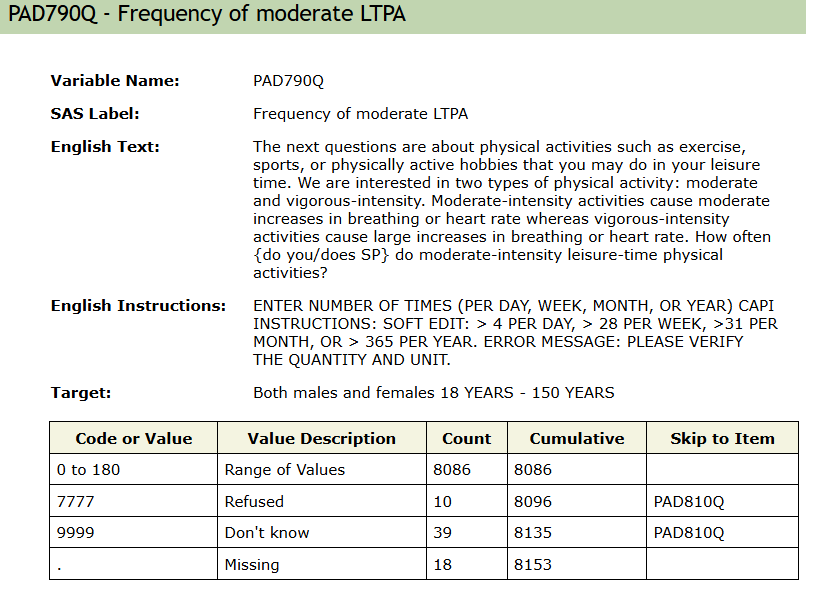


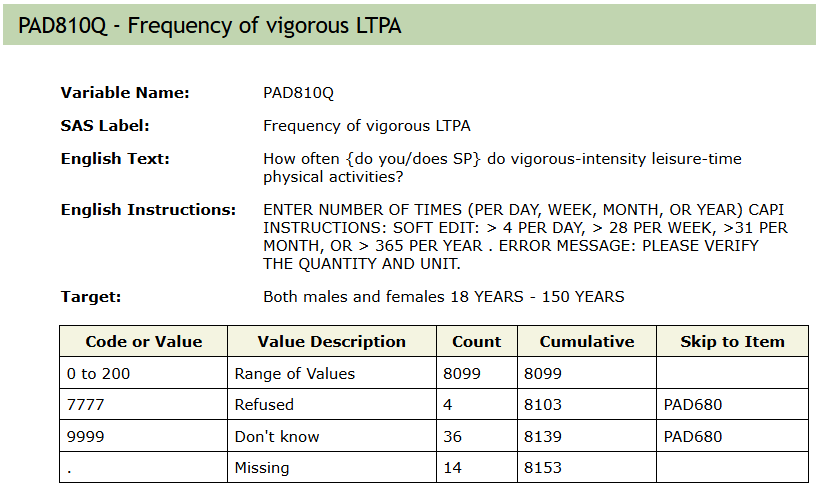

In [121]:
FREQ = ["PAD790Q", "PAD810Q"]

In [122]:
df[FREQ].describe()

,PAD790Q,PAD810Q
count,6330.000000,6330.000000
mean,49.507425,41.875987
std,670.693223,634.616025
min,0.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,0.000000
75%,4.000000,2.000000
max,9999.000000,9999.000000


In [123]:
df[FREQ].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PAD790Q  6330 non-null   float64
 1   PAD810Q  6330 non-null   float64
dtypes: float64(2)
memory usage: 99.1 KB


In [124]:
df[(df["PAD790Q"] > 4) & (df["PAD790Q"] < 7777)]  # noqa: PLR2004


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,DMDHHSIZ,DMDMARTZ,BMXBMI,BMXWAIST,...,ALQ170,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680,WTMEC2YR,DIQ010
5,130388,27,2,4,4.0,0.81,5,1.0,43.7,118.5,...,NaN,5.0,W,180.0,0.0,NaN,NaN,360.0,30329.53643,2
11,130394,51,1,3,5.0,5.00,4,1.0,24.4,92.1,...,NaN,7.0,W,45.0,4.0,W,30.0,420.0,51305.02443,2
15,130398,47,1,1,3.0,1.67,2,1.0,28.7,94.8,...,NaN,7.0,W,120.0,2.0,Y,60.0,60.0,62720.64227,2
16,130399,68,1,3,5.0,5.00,2,1.0,22.7,86.0,...,NaN,6.0,W,90.0,2.0,W,60.0,360.0,43156.69879,2
20,130404,73,2,3,4.0,4.42,1,2.0,25.7,103.0,...,NaN,5.0,W,50.0,3.0,W,30.0,120.0,26881.75069,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6307,142263,44,2,3,5.0,NaN,1,2.0,22.6,80.4,...,NaN,5.0,W,90.0,5.0,W,90.0,480.0,28314.19648,2
6309,142266,66,2,4,3.0,0.91,1,2.0,30.2,108.6,...,NaN,7.0,W,30.0,0.0,NaN,NaN,480.0,30566.66288,2
6311,142268,32,1,4,3.0,1.17,2,1.0,23.5,88.9,...,1.0,6.0,W,360.0,1.0,W,120.0,300.0,43789.13545,2
6313,142273,18,1,6,NaN,1.02,4,NaN,20.0,71.5,...,NaN,5.0,W,60.0,5.0,W,60.0,420.0,57136.63785,2


In [125]:
df[(df["PAD810Q"] > 4) & (df["PAD810Q"] < 7777)]  # noqa: PLR2004

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,DMDHHSIZ,DMDMARTZ,BMXBMI,BMXWAIST,...,ALQ170,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,PAD680,WTMEC2YR,DIQ010
35,130430,27,2,3,5.0,3.43,5,3.0,22.2,77.4,...,0.0,2.0,W,45.0,5.0,W,30.0,720.0,128693.10690,2
38,130436,50,1,3,5.0,5.00,2,1.0,31.9,105.0,...,0.0,7.0,W,60.0,7.0,W,60.0,180.0,44685.66159,2
50,130457,38,2,3,5.0,5.00,1,3.0,23.0,78.0,...,NaN,6.0,W,120.0,5.0,W,60.0,780.0,19115.03948,2
63,130492,18,2,3,NaN,2.98,6,NaN,41.0,118.6,...,NaN,7.0,W,180.0,7.0,W,60.0,180.0,17357.77060,2
67,130497,74,1,3,3.0,2.06,1,2.0,32.4,109.1,...,0.0,5.0,W,150.0,5.0,W,30.0,480.0,44117.39511,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6262,142179,24,2,7,3.0,0.21,2,1.0,19.8,72.7,...,0.0,3.0,W,360.0,8.0,M,90.0,600.0,87205.82096,2
6284,142216,57,2,3,4.0,3.60,4,1.0,24.5,90.1,...,0.0,4.0,W,720.0,5.0,W,45.0,180.0,135551.63810,2
6303,142253,74,2,3,5.0,2.74,1,2.0,27.3,91.2,...,NaN,1.0,D,60.0,24.0,Y,30.0,240.0,11954.68657,2
6307,142263,44,2,3,5.0,NaN,1,2.0,22.6,80.4,...,NaN,5.0,W,90.0,5.0,W,90.0,480.0,28314.19648,2


In [126]:
# Replace sentinel 9999 with NA for PAD790Q and PAD810Q
cols = ["PAD790Q", "PAD810Q"]

for col in cols:
    before_count = (df[col] == 9999).sum()
    df[col] = df[col].replace(9999, pd.NA)
    after_na = df[col].isna().sum()
    print(f"{col}: replaced {before_count} occurrences of 9999 -> now {after_na} missing")


PAD790Q: replaced 25 occurrences of 9999 -> now 32 missing
PAD810Q: replaced 25 occurrences of 9999 -> now 32 missing


### Unit Features

* **PAD790U** - Moderate activity unit (D/W/M/Y) [Categorical]
* **PAD810U** - Vigorous activity unit (D/W/M/Y) [Categorical]

In [127]:
UNIT_FEATURES = ["PAD790U", "PAD810U"]

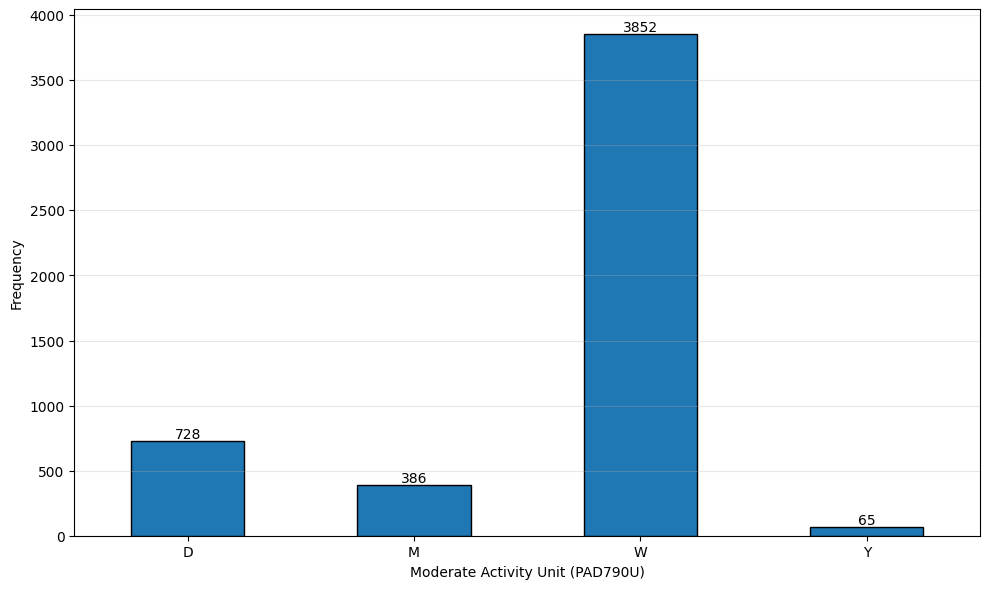

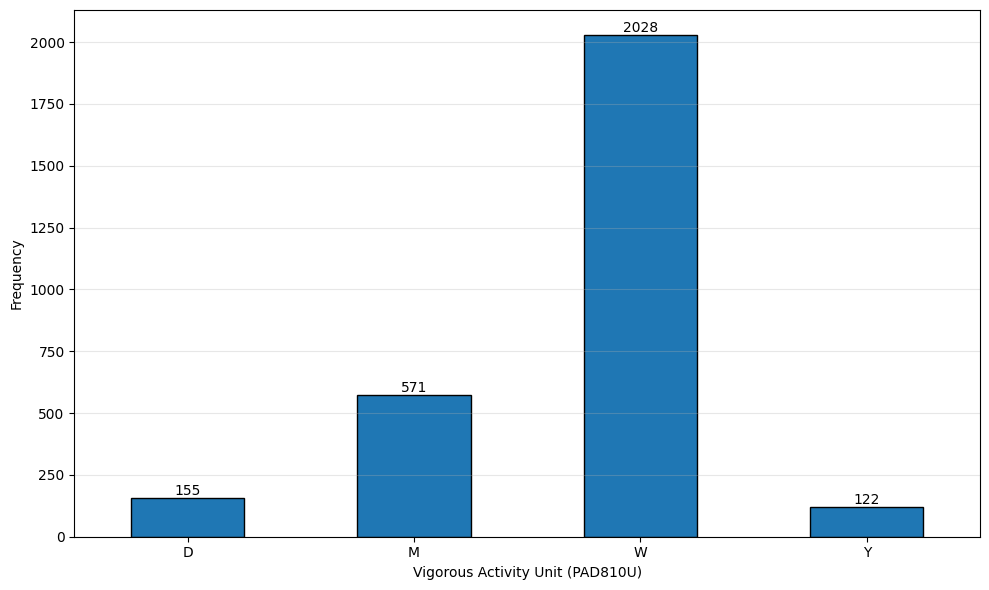

In [128]:
plot_value_counts(df, "PAD790U", xlabel="Moderate Activity Unit (PAD790U)")
plot_value_counts(df, "PAD810U", xlabel="Vigorous Activity Unit (PAD810U)")

In [129]:
# Transform unit features to numerical "every_X_days" representation
# D (Daily) -> 1 (frequency per 1 day)
# W (Weekly) -> 7 (frequency per 7 days)
# M (Monthly) -> 30 (frequency per 30 days)
# Y (Yearly) -> 365 (frequency per 365 days)

unit_to_days_mapping = {
    'D': 1,
    'W': 7,
    'M': 30,
    'Y': 365
}

# Get position of original unit columns to insert new features there
pad790u_pos = df.columns.get_loc('PAD790U')
pad810u_pos = df.columns.get_loc('PAD810U')

# Transform moderate activity unit
df.insert(pad790u_pos + 1, 'moderate_every_X_days', df['PAD790U'].map(unit_to_days_mapping)) # type: ignore

# Transform vigorous activity unit (position adjusted because we inserted moderate_every_X_days)
df.insert(pad810u_pos + 2, 'vigorous_every_X_days', df['PAD810U'].map(unit_to_days_mapping)) # type: ignore

# Verify the transformation
print("Unit transformation to 'every_X_days':")
print("\nOriginal PAD790U vs moderate_every_X_days:")
print(pd.crosstab(df['PAD790U'].fillna('Missing'),  # pyright: ignore[reportUnknownMemberType]
                  df['moderate_every_X_days'].fillna(-999),  # -999 only for display, doesn't modify df # type: ignore
                  rownames=['PAD790U'],
                  colnames=['moderate_every_X_days']))

print("\nOriginal PAD810U vs vigorous_every_X_days:")
print(pd.crosstab(df['PAD810U'].fillna('Missing'),  # pyright: ignore[reportUnknownMemberType]
                  df['vigorous_every_X_days'].fillna(-999),  # -999 only for display, doesn't modify df # type: ignore
                  rownames=['PAD810U'],
                  colnames=['vigorous_every_X_days']))

# Drop original unit columns
df = df.drop(columns=['PAD790U', 'PAD810U'])

print("\nOriginal unit columns (PAD790U, PAD810U) have been removed.")
print(f"Remaining columns in df: {df.shape[1]}")

Unit transformation to 'every_X_days':

Original PAD790U vs moderate_every_X_days:
moderate_every_X_days  -999.0   1.0     7.0     30.0    365.0
PAD790U                                                      
D                           0     728       0       0       0
M                           0       0       0     386       0
Missing                  1306       0       0       0       0
W                           0       0    3852       0       0
Y                           0       0       0       0      65

Original PAD810U vs vigorous_every_X_days:
vigorous_every_X_days  -999.0   1.0     7.0     30.0    365.0
PAD810U                                                      
D                           0     155       0       0       0
M                           0       0       0     571       0
Missing                  3461       0       0       0       0
W                           0       0    2028       0       0
Y                           0       0       0       0     122

Orig

### Minutes of activity features

* **PAD800** - Moderate activity minutes per session

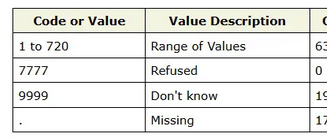



* **PAD820** - Vigorous activity minutes per session

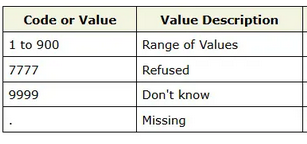

* **PAD680** - Sedentary minutes per day

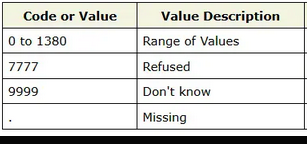

In [130]:
MIN_FEATURES = ["PAD800", "PAD820", "PAD680"]

In [131]:
df[MIN_FEATURES].describe()

,PAD800,PAD820,PAD680
count,5031.000000,2877.000000,6331.000000
mean,88.863248,94.047967,426.807929
std,507.935863,576.484296,792.942690
min,1.000000,1.000000,0.000000
25%,30.000000,30.000000,240.000000
50%,60.000000,45.000000,300.000000
75%,60.000000,60.000000,480.000000
max,9999.000000,9999.000000,9999.000000


In [132]:
df[df[MIN_FEATURES[0]] > 720]["PAD800"].value_counts()  # noqa: PLR2004

PAD800
9999.0    13
Name: count, dtype: int64

In [133]:
df[df[MIN_FEATURES[1]] > 900]["PAD820"].value_counts()  # noqa: PLR2004


PAD820
9999.0    9
7777.0    1
Name: count, dtype: int64

In [134]:
df[df[MIN_FEATURES[2]] > 1380]["PAD680"].value_counts()  # noqa: PLR2004

PAD680
9999.0    39
7777.0     2
Name: count, dtype: int64

In [135]:
# Replace sentinel 9999 with NA for PAD790Q and PAD810Q
cols = ["PAD800", "PAD820", "PAD680"]

for col in cols:
    before_count = (df[col] == 9999).sum()
    df[col] = df[col].replace(9999, pd.NA)
    after_na = df[col].isna().sum()
    print(f"{col}: replaced {before_count} occurrences of 9999 -> now {after_na} missing")

PAD800: replaced 13 occurrences of 9999 -> now 1319 missing
PAD820: replaced 9 occurrences of 9999 -> now 3469 missing
PAD680: replaced 39 occurrences of 9999 -> now 45 missing


# Feature Engineering

## Target Variable

### Diabetes/Prediabetes Status

**Source:** `DIQ010` - "Doctor told you have diabetes?"

**Original Codes:**
- 1 = Yes (Diabetes)
- 2 = No
- 3 = Borderline (Prediabetes)
- 7 = Refused
- 9 = Don't know

**Decision:** Create binary target `has_diabetes_or_prediabetes` combining diabetes + prediabetes as positive class

**Implementation:**
- Positive (1): DIQ010 in [1, 3] (Diabetes OR Prediabetes)
- Negative (0): DIQ010 == 2 (No diabetes)
- Exclude: DIQ010 in [7, 9] (Refused/Don't know)

**Rationale:**
- Combines diabetes + prediabetes for conservative screening approach
- Same metabolic pathway (insulin resistance)
- ~70% of prediabetes progresses to diabetes
- Both benefit from early intervention
- Shared risk factors (obesity, inactivity, family history)

In [136]:
# Check current DIQ010 values
print("DIQ010 (Doctor told you have diabetes) value counts:")
print(df['DIQ010'].value_counts(dropna=False).sort_index())
print(f"\nTotal records: {len(df)}")
print(f"Missing values: {df['DIQ010'].isna().sum()}")

DIQ010 (Doctor told you have diabetes) value counts:
DIQ010
1     870
2    5243
3     223
9       1
Name: count, dtype: int64

Total records: 6337
Missing values: 0


In [137]:
# Create binary target variable: has_diabetes_or_prediabetes
# Positive class: Diabetes (1) OR Prediabetes (3)
# Negative class: No diabetes (2)
# Exclude: Refused (7) and Don't know (9) - set to NaN

df['has_diabetes_or_prediabetes'] = df['DIQ010'].map({
    1: 1,  # Yes (Diabetes)
    2: 0,  # No
    3: 1,  # Borderline (Prediabetes)
    # 7 and 9 will become NaN (refused/don't know)
})

# Verify the transformation
print("Target variable transformation:")
print(f"\nhas_diabetes_or_prediabetes distribution:")
print(df['has_diabetes_or_prediabetes'].value_counts(dropna=False))

print(f"\nClass distribution:")
positive = (df['has_diabetes_or_prediabetes'] == 1).sum()
negative = (df['has_diabetes_or_prediabetes'] == 0).sum()
excluded = df['has_diabetes_or_prediabetes'].isna().sum()

print(f"Positive (Diabetes + Prediabetes): {positive} ({positive / (positive + negative) * 100:.1f}%)")
print(f"Negative (No diabetes): {negative} ({negative / (positive + negative) * 100:.1f}%)")
print(f"Excluded (Refused/Don't know): {excluded}")
print(f"Class imbalance ratio: 1:{negative / positive:.1f}")

# Cross-tabulation to verify encoding
print("\nCross-tabulation (DIQ010 vs has_diabetes_or_prediabetes):")
print(pd.crosstab(df['DIQ010'].fillna(-999),  # type: ignore
                  df['has_diabetes_or_prediabetes'].fillna(-999), # type: ignore
                  rownames=['DIQ010_original'],
                  colnames=['has_diabetes_or_prediabetes'],
                  margins=True))

Target variable transformation:

has_diabetes_or_prediabetes distribution:
has_diabetes_or_prediabetes
0.0    5243
1.0    1093
NaN       1
Name: count, dtype: int64

Class distribution:
Positive (Diabetes + Prediabetes): 1093 (17.3%)
Negative (No diabetes): 5243 (82.7%)
Excluded (Refused/Don't know): 1
Class imbalance ratio: 1:4.8

Cross-tabulation (DIQ010 vs has_diabetes_or_prediabetes):
has_diabetes_or_prediabetes  -999.0   0.0   1.0   All
DIQ010_original                                      
1                                 0     0   870   870
2                                 0  5243     0  5243
3                                 0     0   223   223
9                                 1     0     0     1
All                               1  5243  1093  6337


In [138]:
df['has_diabetes_or_prediabetes'].value_counts(dropna=False)

has_diabetes_or_prediabetes
0.0    5243
1.0    1093
NaN       1
Name: count, dtype: int64

In [139]:
# Check current distribution before filtering
print("Before filtering:")
print(f"has_diabetes_or_prediabetes value counts:")
print(df['has_diabetes_or_prediabetes'].value_counts(dropna=False))
print(f"Total rows: {len(df)}")

# Filter out rows where has_diabetes_or_prediabetes is not 0 or 1
df = df[df['has_diabetes_or_prediabetes'].isin([0, 1])].copy()

# Verify after filtering
print("\nAfter filtering:")
print(f"has_diabetes_or_prediabetes value counts:")
print(df['has_diabetes_or_prediabetes'].value_counts(dropna=False))
print(f"Total rows: {len(df)}")
print(f"Rows removed: {6337 - len(df)}")

# Convert has_diabetes_or_prediabetes to int (since it only contains 0 and 1 now)
df['has_diabetes_or_prediabetes'] = df['has_diabetes_or_prediabetes'].astype(int)
print(f"\nTarget variable dtype: {df['has_diabetes_or_prediabetes'].dtype}")

Before filtering:
has_diabetes_or_prediabetes value counts:
has_diabetes_or_prediabetes
0.0    5243
1.0    1093
NaN       1
Name: count, dtype: int64
Total rows: 6337

After filtering:
has_diabetes_or_prediabetes value counts:
has_diabetes_or_prediabetes
0.0    5243
1.0    1093
Name: count, dtype: int64
Total rows: 6336
Rows removed: 1

Target variable dtype: int64


In [140]:
# Drop the original DIQ010 column
df = df.drop(columns=['DIQ010'])

print("Original DIQ010 column has been removed.")
print(f"Remaining columns in df: {df.shape[1]}")
print(f"\nTarget variable 'has_diabetes_or_prediabetes' created successfully!")

Original DIQ010 column has been removed.
Remaining columns in df: 33

Target variable 'has_diabetes_or_prediabetes' created successfully!


## Demographics

### Education Level

**Source:** `DMDEDUC2`

**Categories:**
1. Less than 9th grade
2. 9-11th grade (no diploma)
3. High school/GED
4. Some college/AA
5. College graduate+

**Decision:** Simple Ordinal Encoding (1-5)

**Rationale:** Tree-based models natively evaluate all possible threshold splits on ordinal features. Ordinal encoding preserves the natural ordering while keeping it as a single feature (cleaner than one-hot encoding).

In [141]:
# Check current education level values
print("Education level (DMDEDUC2) value counts:")  # noqa: T201
print(df["DMDEDUC2"].value_counts(dropna=False).sort_index())  # noqa: T201
print(f"\nMissing values: {df['DMDEDUC2'].isna().sum()}")  # noqa: T201


Education level (DMDEDUC2) value counts:
DMDEDUC2
1.0     292
2.0     482
3.0    1297
4.0    1846
5.0    2143
9.0       4
NaN     272
Name: count, dtype: int64

Missing values: 272


In [142]:
df[(df["DMDEDUC2"] == 9) & (df["RIDAGEYR"] >= 20)]  # noqa: PLR2004


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,DMDHHSIZ,DMDMARTZ,BMXBMI,BMXWAIST,...,ALQ170,PAD790Q,moderate_every_X_days,PAD800,PAD810Q,vigorous_every_X_days,PAD820,PAD680,WTMEC2YR,has_diabetes_or_prediabetes
664,131639,63,1,3,9.0,NaN,1,2.0,25.9,99.0,...,NaN,7.0,7.0,5.0,0.0,NaN,NaN,180.0,21426.84650,0
921,132117,80,1,2,9.0,0.18,1,2.0,NaN,NaN,...,NaN,7.0,7.0,15.0,3.0,7.0,15.0,480.0,15453.53543,1
3480,136971,67,2,4,9.0,3.28,2,2.0,29.7,109.2,...,NaN,4.0,7.0,30.0,0.0,NaN,NaN,180.0,28576.18940,1
4452,138757,40,2,3,9.0,4.37,2,3.0,27.1,83.1,...,NaN,0.0,NaN,NaN,0.0,NaN,NaN,480.0,19955.09345,0


In [143]:
df[(df["DMDEDUC2"].isna()) & (df["RIDAGEYR"] >= 20)]  # noqa: PLR2004


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,DMDHHSIZ,DMDMARTZ,BMXBMI,BMXWAIST,...,ALQ170,PAD790Q,moderate_every_X_days,PAD800,PAD810Q,vigorous_every_X_days,PAD820,PAD680,WTMEC2YR,has_diabetes_or_prediabetes


In [144]:
# Ordinal encoding: recode 9 ("Don't know") to 0, keep 1-5 as is
# This gives us ordinal values: 0 (Don't know), 1-5 (education levels)
# NaN values are people under 20 who weren't asked this question
df['education_level'] = df['DMDEDUC2'].replace({9: 0}).copy() # type: ignore

# Verify the transformation
print("Transformed education_level:")
print(df['education_level'].value_counts(dropna=False).sort_index())
print(f"\nData type: {df['education_level'].dtype}")
print(f"\nMissing values (under 20 years old): {df['education_level'].isna().sum()}")

Transformed education_level:
education_level
0.0       4
1.0     292
2.0     482
3.0    1297
4.0    1846
5.0    2143
NaN     272
Name: count, dtype: int64

Data type: float64

Missing values (under 20 years old): 272


In [145]:
# Drop the original education column now that 'education_level' exists
df = df.drop(columns=['DMDEDUC2'])

print("Original DMDEDUC2 column has been removed.")
print(f"Remaining columns in df: {df.shape[1]}")

Original DMDEDUC2 column has been removed.
Remaining columns in df: 33


### Marital Status

**Source:** `DMDMARTZ`

**Categories:**
- 1 = Married/Living with partner
- 2 = Widowed/Divorced/Separated
- 3 = Never married
- 77 = Refused
- 99 = Don't know

**Decision:** One-Hot Encoding (k-1 approach)

**Implementation:**
- Create `has_partner` (1 if code=1, else 0)
- Create `had_partner` (1 if code=2, else 0)
- Reference level: Never married (3) + Refused (77) + Don't know (99) + Missing

**Rationale:** Marital status is nominal (no natural ordering), so one-hot encoding is appropriate. Using k-1 approach avoids multicollinearity.

In [146]:
# One-hot encoding (k-1 approach)
# Create binary features for first 2 categories, 3rd becomes reference level
df["has_partner"] = (df["DMDMARTZ"] == 1).astype(int)
df["had_partner"] = (df["DMDMARTZ"] == 2).astype(int)  # noqa: PLR2004

# Reference level: Never married (3) + Refused (77) + Don't know (99) + Missing
# These will have both has_partner=0 and had_partner=0

# Verify the transformation
print("Marital status transformation:")  # noqa: T201
print(f"\nhas_partner distribution:")  # noqa: F541, T201
print(df["has_partner"].value_counts(dropna=False))  # noqa: T201
print(f"\nhad_partner distribution:")  # noqa: F541, T201
print(df["had_partner"].value_counts(dropna=False))  # noqa: T201

# Cross-tabulation to verify encoding
print("\nCross-tabulation (DMDMARTZ vs new features):")  # noqa: T201
print(pd.crosstab([df["DMDMARTZ"].fillna("Missing")],  # noqa: T201 # pyright: ignore[reportUnknownMemberType]
                  [df["has_partner"], df["had_partner"]],
                  rownames=["Original"],
                  colnames=["has_partner", "had_partner"]))

Marital status transformation:

has_partner distribution:
has_partner
1    3277
0    3059
Name: count, dtype: int64

had_partner distribution:
had_partner
0    4800
1    1536
Name: count, dtype: int64

Cross-tabulation (DMDMARTZ vs new features):
has_partner     0           1
had_partner     0     1     0
Original                     
1.0             0     0  3277
2.0             0  1536     0
3.0          1246     0     0
77.0            1     0     0
99.0            3     0     0
Missing       273     0     0


In [147]:
# Drop the original DMDMARTZ column since we've created the binary features
df = df.drop(columns=['DMDMARTZ'])

print("Original DMDMARTZ column has been removed.")
print(f"Remaining columns in df: {df.shape[1]}")

Original DMDMARTZ column has been removed.
Remaining columns in df: 34


### Gender

**Source:** `RIAGENDR`

**Categories:**
- 1 = Male
- 2 = Female

**Decision:** One-Hot Encoding (k-1 approach)

**Implementation:**
- Create `is_female` (1 if code=2, else 0)
- Reference level: Male (code=1)

**Rationale:** Binary categorical variable with no natural ordering. Using k-1 approach (single binary feature) to represent gender while avoiding multicollinearity. Male serves as the reference category.

In [148]:
# Check current gender values
print("Gender (RIAGENDR) value counts:")
print(df["RIAGENDR"].value_counts(dropna=False).sort_index())
print(f"\nMissing values: {df['RIAGENDR'].isna().sum()}")

Gender (RIAGENDR) value counts:
RIAGENDR
1    2857
2    3479
Name: count, dtype: int64

Missing values: 0


In [149]:
# Create binary feature: is_female
df['is_female'] = (df['RIAGENDR'] == 2).astype(int)

# Verify the transformation
print("Gender transformation:")
print(f"\nis_female distribution:")
print(df['is_female'].value_counts(dropna=False))

# Cross-tabulation to verify encoding
print("\nCross-tabulation (RIAGENDR vs is_female):")
print(pd.crosstab(df['RIAGENDR'].fillna('Missing'),  # pyright: ignore[reportUnknownMemberType]
                  df['is_female'],
                  rownames=['Original Gender'],
                  colnames=['is_female']))

Gender transformation:

is_female distribution:
is_female
1    3479
0    2857
Name: count, dtype: int64

Cross-tabulation (RIAGENDR vs is_female):
is_female           0     1
Original Gender            
1                2857     0
2                   0  3479


In [150]:
# Drop the original RIAGENDR column
df = df.drop(columns=['RIAGENDR'])

print("Original RIAGENDR column has been removed.")
print(f"Remaining columns in df: {df.shape[1]}")

Original RIAGENDR column has been removed.
Remaining columns in df: 34


## Blood Pressure

### 11.7 Blood Pressure Averaging

**Original Features:**
- Systolic: `BPXOSY1`, `BPXOSY2`, `BPXOSY3`
- Diastolic: `BPXODI1`, `BPXODI2`, `BPXODI3`

**Decision:** Average per-row across available (non-null) measurements

**Implementation:**
- Create `systolic_bp` = mean of 3 systolic readings
- Create `diastolic_bp` = mean of 3 diastolic readings

**Rationale:** Averaging multiple readings reduces measurement variability (standard clinical practice). Using row-wise mean handles missing values automatically.

In [151]:
# Check current blood pressure values
systolic_cols = ['BPXOSY1', 'BPXOSY2', 'BPXOSY3']
diastolic_cols = ['BPXODI1', 'BPXODI2', 'BPXODI3']

print("Systolic Blood Pressure Readings:")
print(df[systolic_cols].describe())
print(f"\nDiastolic Blood Pressure Readings:")
print(df[diastolic_cols].describe())

Systolic Blood Pressure Readings:
           BPXOSY1      BPXOSY2      BPXOSY3
count  6122.000000  6115.000000  6100.000000
mean    122.564195   122.416026   122.213443
std      18.452247    18.398435    18.294650
min      73.000000    65.000000    62.000000
25%     110.000000   110.000000   110.000000
50%     120.000000   120.000000   120.000000
75%     133.000000   132.000000   132.000000
max     232.000000   233.000000   232.000000

Diastolic Blood Pressure Readings:
           BPXODI1      BPXODI2      BPXODI3
count  6122.000000  6115.000000  6100.000000
mean     74.977132    74.314473    73.959344
std      11.415922    11.325775    11.233440
min      36.000000    32.000000    26.000000
25%      67.000000    67.000000    66.000000
50%      74.000000    74.000000    73.000000
75%      82.000000    81.000000    81.000000
max     142.000000   139.000000   136.000000


In [152]:
# Average blood pressure readings across the 3 measurements
df['systolic_bp'] = df[systolic_cols].mean(axis=1)
df['diastolic_bp'] = df[diastolic_cols].mean(axis=1)

# Verify the transformation
print("Blood pressure transformation:")
print(f"\nsystolic_bp:")
print(df['systolic_bp'].describe())
print(f"\ndiastolic_bp:")
print(df['diastolic_bp'].describe())
print(f"\nMissing values:")
print(f"systolic_bp: {df['systolic_bp'].isna().sum()}")
print(f"diastolic_bp: {df['diastolic_bp'].isna().sum()}")

Blood pressure transformation:

systolic_bp:
count    6122.000000
mean      122.414353
std        17.999603
min        70.000000
25%       110.333333
50%       120.000000
75%       132.000000
max       232.333333
Name: systolic_bp, dtype: float64

diastolic_bp:
count    6122.000000
mean       74.418463
std        11.026090
min        34.000000
25%        66.666667
50%        73.666667
75%        81.000000
max       139.000000
Name: diastolic_bp, dtype: float64

Missing values:
systolic_bp: 214
diastolic_bp: 214


In [153]:
# Drop the original blood pressure columns
df = df.drop(columns=systolic_cols + diastolic_cols)

print("Original blood pressure columns have been removed.")
print(f"Remaining columns in df: {df.shape[1]}")

Original blood pressure columns have been removed.
Remaining columns in df: 30


## Smoking

### 11.8 Smoking Features

**Original Features:**
- `SMQ020`: Ever smoked 100+ cigarettes (1=Yes, 2=No, 7=Refused, 9=Don't know)
- `SMQ040`: Current smoking status (1=Every day, 2=Some days, 3=Not at all)
- `SMD650`: Cigarettes per day (85% missing, redundant)

**Decision:** Create 2 binary features from SMQ020+SMQ040, drop SMD650

**Implementation:**
1. Clean SMQ020: Recode refused (7) and don't know (9) → never smokers (2)
2. Create `ever_smoker`: Binary from cleaned SMQ020 (1=ever, 0=never)
3. Create `is_current_smoker`: Binary combining both (1 if ever smoked AND currently smoking)

**Rationale:** 
- Refused/don't know about 100+ cigarettes indicates minimal smoking
- Current smoker properly handles skip logic (non-smokers skip SMQ040)
- SMD650 has 85% missingness and low predictive value

In [154]:
# Check current smoking feature values
print("SMQ020 (Ever smoked 100+ cigarettes) value counts:")
print(df['SMQ020'].value_counts(dropna=False).sort_index())
print(f"\nSMQ040 (Current smoking status) value counts:")
print(df['SMQ040'].value_counts(dropna=False).sort_index())
print(f"\nSMD650 (Cigarettes per day) - missingness:")
print(f"Missing: {df['SMD650'].isna().sum()} ({(df['SMD650'].isna().sum() / len(df)) * 100:.1f}%)")

SMQ020 (Ever smoked 100+ cigarettes) value counts:
SMQ020
1.0    2518
2.0    3809
7.0       3
9.0       4
NaN       2
Name: count, dtype: int64

SMQ040 (Current smoking status) value counts:
SMQ040
1.0     741
2.0     180
3.0    1597
NaN    3818
Name: count, dtype: int64

SMD650 (Cigarettes per day) - missingness:
Missing: 5424 (85.6%)


In [155]:
# Step 1: Clean SMQ020 - recode refused/don't know as never smokers
df['SMQ020_clean'] = df['SMQ020'].replace({7: 2, 9: 2}) # type: ignore

# Step 2: Create ever_smoker binary feature
# 1 = ever smoked 100+ cigarettes, 0 = never smoked, NaN = missing
df['ever_smoker'] = df['SMQ020_clean'].map({1: 1, 2: 0})

# Step 3: Create is_current_smoker binary feature
# Current smoker = 1 if ever smoked (SMQ020==1) AND currently smoking (SMQ040 in [1,2])
df['is_current_smoker'] = (
    (df['SMQ020_clean'] == 1) & 
    (df['SMQ040'].isin([1, 2])) # type: ignore
).astype(int)

# Verify the transformation
print("Smoking features transformation:")
print(f"\never_smoker distribution:")
print(df['ever_smoker'].value_counts(dropna=False))
print(f"\nis_current_smoker distribution:")
print(df['is_current_smoker'].value_counts(dropna=False))

# Cross-tabulation to verify logic
print("\nCross-tabulation (ever_smoker vs is_current_smoker):")
print(pd.crosstab(df['ever_smoker'].fillna(-1),  # type: ignore
                  df['is_current_smoker'],
                  rownames=['ever_smoker'],
                  colnames=['is_current_smoker'],
                  margins=True))

Smoking features transformation:

ever_smoker distribution:
ever_smoker
0.0    3816
1.0    2518
NaN       2
Name: count, dtype: int64

is_current_smoker distribution:
is_current_smoker
0    5415
1     921
Name: count, dtype: int64

Cross-tabulation (ever_smoker vs is_current_smoker):
is_current_smoker     0    1   All
ever_smoker                       
-1.0                  2    0     2
 0.0               3816    0  3816
 1.0               1597  921  2518
 All               5415  921  6336


In [156]:
# Drop original smoking columns and temporary cleaning column
df = df.drop(columns=['SMQ020', 'SMQ020_clean', 'SMQ040', 'SMD650'])

print("Original smoking columns have been removed.")
print(f"Remaining columns in df: {df.shape[1]}")

Original smoking columns have been removed.
Remaining columns in df: 29


## Alcohol Consumption

### 11.9 Alcohol Features

**Original Features:**
- `ALQ121`: Drinking frequency (0-10 scale: 0=Never → 10=Every day, plus 77=Refused, 99=Don't know)
- `ALQ130`: Average drinks per day (continuous, 1-15+, plus 777=Refused, 999=Don't know)
- `ALQ170`: Binge drinking episodes in past month (continuous, 0-30+, plus 777=Refused, 999=Don't know)

**Decision:** Group ALQ121 into 5 ordinal categories; convert refused/don't know to NaN for all features

**Implementation:**
1. Clean refused (77/777) and don't know (99/999) → NaN
2. Group ALQ121: 11 categories → 5 ordinal levels (Never, Occasional, Monthly, Weekly, Daily)
3. Recode to proper ordinal sequence (0=Never → 4=Daily)
4. Keep ALQ130 and ALQ170 as continuous (with cleaned NaN values)

**Rationale:**
- Refused/don't know: Tree models handle NaN natively
- Grouping: Preserves dose-response relationship while improving efficiency
- Ordinal encoding: Single feature more efficient than one-hot encoding
- Complementary features: Frequency + intensity + binge pattern = comprehensive profile

In [157]:
# Check current alcohol feature values before transformation
print("ALQ121 (Drinking frequency) value counts:")
print(df['ALQ121'].value_counts(dropna=False).sort_index())
print(f"\nALQ130 (Drinks per day) - sample values and special codes:")
print(df['ALQ130'].value_counts(dropna=False).sort_index().tail(10))
print(f"\nALQ170 (Binge episodes) - sample values and special codes:")
print(df['ALQ170'].value_counts(dropna=False).sort_index().tail(10))

ALQ121 (Drinking frequency) value counts:
ALQ121
0.0      836
1.0      163
2.0      301
3.0      458
4.0      483
5.0      420
6.0      574
7.0      362
8.0      261
9.0      517
10.0     541
77.0       2
99.0       3
NaN     1415
Name: count, dtype: int64

ALQ130 (Drinks per day) - sample values and special codes:
ALQ130
9.0        19
10.0       31
11.0        4
12.0       55
13.0        1
14.0        2
15.0       20
777.0       4
999.0      10
NaN      2268
Name: count, dtype: int64

ALQ170 (Binge episodes) - sample values and special codes:
ALQ170
13.0        1
14.0        1
15.0       10
17.0        1
18.0        3
20.0       31
30.0       43
777.0       3
999.0       3
NaN      3978
Name: count, dtype: int64


In [158]:
# Step 1: Clean refused/don't know codes → NaN
df['ALQ121'] = df['ALQ121'].replace({77: pd.NA, 99: pd.NA}) # type: ignore
df['ALQ130'] = df['ALQ130'].replace({777: pd.NA, 999: pd.NA}) # type: ignore
df['ALQ170'] = df['ALQ170'].replace({777: pd.NA, 999: pd.NA}) # type: ignore

# Step 2: Group ALQ121 into intermediate categories
alq121_grouped = df['ALQ121'].map({
    0: 0,   # Never in last year
    1: 1, 2: 1,   # Every day, Nearly every day → Daily
    3: 2, 4: 2,   # 3-4x/week, 2x/week → Weekly
    5: 3, 6: 3, 7: 3,   # Once/week, 2-3x/month, Once/month → Monthly
    8: 4, 9: 4, 10: 4   # 7-11x/year, 3-6x/year, 1-2x/year → Occasional
})

# Step 3: Recode to proper ordinal sequence (0=Never → 4=Daily)
df['drinking_frequency'] = alq121_grouped.map({
    0: 0,  # Never
    4: 1,  # Occasional/Rare (< once/month)
    3: 2,  # Monthly (1-4 times/month)
    2: 3,  # Weekly (2+ times/week)
    1: 4   # Daily/Near-daily
})

# Step 4: Keep other alcohol features as continuous (with cleaned values)
# Convert to numeric to ensure proper data type (not object)
df['drinks_per_day'] = pd.to_numeric(df['ALQ130'], errors='coerce') # type: ignore
df['binge_episodes_month'] = pd.to_numeric(df['ALQ170'], errors='coerce') # type: ignore

# Verify the transformation
print("Alcohol features transformation:")
print(f"\ndrinking_frequency distribution:")
print(df['drinking_frequency'].value_counts(dropna=False).sort_index())
print(f"\ndrinks_per_day summary (dtype: {df['drinks_per_day'].dtype}):")
print(df['drinks_per_day'].describe())
print(f"\nbinge_episodes_month summary (dtype: {df['binge_episodes_month'].dtype}):")
print(df['binge_episodes_month'].describe())

# Cross-tabulation: original ALQ121 vs new drinking_frequency
print("\nCross-tabulation (original ALQ121 vs drinking_frequency):")
print(pd.crosstab(df['ALQ121'].fillna(-999),  # type: ignore
                  df['drinking_frequency'].fillna(-999), # type: ignore
                  rownames=['ALQ121_original'],
                  colnames=['drinking_frequency'],
                  margins=True))

Alcohol features transformation:

drinking_frequency distribution:
drinking_frequency
0.0     836
1.0    1319
2.0    1356
3.0     941
4.0     464
NaN    1420
Name: count, dtype: int64

drinks_per_day summary (dtype: float64):
count    4054.000000
mean        2.633448
std         2.220583
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: drinks_per_day, dtype: float64

binge_episodes_month summary (dtype: float64):
count    2352.000000
mean        2.142007
std         4.889966
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        30.000000
Name: binge_episodes_month, dtype: float64

Cross-tabulation (original ALQ121 vs drinking_frequency):
drinking_frequency  -999.0   0.0   1.0   2.0   3.0   4.0   All
ALQ121_original                                               
-999.0                1420     0     0     0     0     0  1420
 0.0                     0   836     0     0     0     0   836

/tmp/ipykernel_115417/3663804692.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(pd.crosstab(df['ALQ121'].fillna(-999),  # type: ignore


In [159]:
# Drop original alcohol columns
df = df.drop(columns=['ALQ121', 'ALQ130', 'ALQ170'])

print("Original alcohol columns have been removed.")
print(f"Remaining columns in df: {df.shape[1]}")
print(f"\nNew alcohol features retained:")
print("- drinking_frequency (ordinal 0-4)")
print("- drinks_per_day (continuous)")
print("- binge_episodes_month (continuous)")

Original alcohol columns have been removed.
Remaining columns in df: 29

New alcohol features retained:
- drinking_frequency (ordinal 0-4)
- drinks_per_day (continuous)
- binge_episodes_month (continuous)


---

## Physical Activity

In [160]:
PA_FEATURES = ["PAD790Q",      # Moderate activity frequency
    "moderate_every_X_days",      # how many days in between
    "PAD800",       # Moderate activity minutes per session
    "PAD810Q",      # Vigorous activity frequency
    "vigorous_every_X_days",      # how many days in between
    "PAD820",       # Vigorous activity minutes per session
    "PAD680",       # Sedentary minutes per day
]

In [161]:
# Replace sentinel 7777 with NA for all PA_FEATURES
for col in PA_FEATURES:
    if col in df.columns:
        before_count = (df[col] == 7777).sum()
        df[col] = df[col].replace(7777, pd.NA) # type: ignore
        after_na = df[col].isna().sum()
        print(f"{col}: replaced {before_count} occurrences of 7777 -> now {after_na} missing")
    else:
        print(f"{col}: column not found, skipping")

PAD790Q: replaced 6 occurrences of 7777 -> now 38 missing
moderate_every_X_days: replaced 0 occurrences of 7777 -> now 1305 missing
PAD800: replaced 0 occurrences of 7777 -> now 1318 missing
PAD810Q: replaced 1 occurrences of 7777 -> now 33 missing
vigorous_every_X_days: replaced 0 occurrences of 7777 -> now 3460 missing
PAD820: replaced 1 occurrences of 7777 -> now 3469 missing
PAD680: replaced 2 occurrences of 7777 -> now 47 missing


In [162]:
# Force PA features to numeric (invalid entries -> NaN)
for col in PA_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce") # type: ignore

# Confirm changes
print(df[PA_FEATURES].dtypes)
df[PA_FEATURES].head()

PAD790Q                  float64
moderate_every_X_days    float64
PAD800                   float64
PAD810Q                  float64
vigorous_every_X_days    float64
PAD820                   float64
PAD680                   float64
dtype: object


,PAD790Q,moderate_every_X_days,PAD800,PAD810Q,vigorous_every_X_days,PAD820,PAD680
0,3.0,7.0,45.0,3.0,7.0,45.0,360.0
1,4.0,7.0,45.0,3.0,7.0,45.0,480.0
2,1.0,7.0,20.0,0.0,NaN,NaN,240.0
3,1.0,7.0,30.0,1.0,30.0,30.0,180.0
4,0.0,NaN,NaN,0.0,NaN,NaN,1200.0


In [163]:
df[PA_FEATURES].describe()

,PAD790Q,moderate_every_X_days,PAD800,PAD810Q,vigorous_every_X_days,PAD820,PAD680
count,6298.000000,5031.000000,5018.000000,6303.000000,2876.000000,2867.000000,6289.000000
mean,2.658781,12.521765,63.189318,1.161828,26.429416,60.274852,365.092384
std,2.820210,40.884037,59.373539,2.378329,71.888684,60.592577,208.965021
min,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,1.000000,7.000000,30.000000,0.000000,7.000000,30.000000,180.000000
50%,2.000000,7.000000,55.000000,0.000000,7.000000,45.000000,300.000000
75%,4.000000,7.000000,60.000000,2.000000,7.000000,60.000000,480.000000
max,104.000000,365.000000,720.000000,90.000000,365.000000,900.000000,1380.000000


## Features to exclude on v1

* Race
* Income to poverty Ratio

In [164]:
df.drop(columns = ['SEQN', 'RIDRETH3', 'INDFMPIR'], inplace=True)

In [165]:
# Move DIQ010 column to the end
cols = [col for col in df.columns if col != 'has_diabetes_or_prediabetes'] + ['has_diabetes_or_prediabetes']
df = df[cols]

In [166]:
df

,RIDAGEYR,DMDHHSIZ,BMXBMI,BMXWAIST,BMXWT,BMXHT,PAD790Q,moderate_every_X_days,PAD800,PAD810Q,...,had_partner,is_female,systolic_bp,diastolic_bp,ever_smoker,is_current_smoker,drinking_frequency,drinks_per_day,binge_episodes_month,has_diabetes_or_prediabetes
0,43,4,27.0,98.3,86.9,179.5,3.0,7.0,45.0,3.0,...,0,0,132.666667,96.000000,1.0,0,NaN,NaN,NaN,0
1,66,2,33.5,114.7,101.8,174.2,4.0,7.0,45.0,3.0,...,0,0,117.000000,78.666667,1.0,0,4.0,3.0,NaN,0
2,44,7,29.7,93.5,69.4,152.9,1.0,7.0,20.0,0.0,...,0,1,109.000000,78.333333,0.0,0,1.0,1.0,NaN,1
3,34,3,30.2,106.1,90.6,173.3,1.0,7.0,30.0,1.0,...,0,0,115.000000,73.666667,1.0,0,3.0,2.0,0.0,0
4,68,1,42.6,122.0,103.5,155.9,0.0,NaN,NaN,0.0,...,0,1,141.333333,76.000000,0.0,0,0.0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6332,76,4,26.4,89.0,60.4,151.4,2.0,7.0,40.0,0.0,...,1,1,143.666667,79.333333,0.0,0,NaN,NaN,NaN,1
6333,49,5,NaN,NaN,NaN,143.8,3.0,7.0,15.0,0.0,...,0,1,130.000000,73.333333,1.0,0,1.0,1.0,NaN,1
6334,50,3,26.4,98.4,79.3,173.3,1.0,7.0,45.0,0.0,...,0,0,108.000000,69.333333,0.0,0,1.0,2.0,NaN,0
6335,40,5,25.5,96.0,81.9,179.1,2.0,1.0,15.0,0.0,...,1,0,126.666667,81.333333,0.0,0,NaN,NaN,NaN,0


In [167]:
df.to_csv("../dataset/processed_data.csv", sep=",", index=False)

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6336 entries, 0 to 6336
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RIDAGEYR                     6336 non-null   int64  
 1   DMDHHSIZ                     6336 non-null   int64  
 2   BMXBMI                       6234 non-null   float64
 3   BMXWAIST                     6018 non-null   float64
 4   BMXWT                        6247 non-null   float64
 5   BMXHT                        6261 non-null   float64
 6   PAD790Q                      6298 non-null   float64
 7   moderate_every_X_days        5031 non-null   float64
 8   PAD800                       5018 non-null   float64
 9   PAD810Q                      6303 non-null   float64
 10  vigorous_every_X_days        2876 non-null   float64
 11  PAD820                       2867 non-null   float64
 12  PAD680                       6289 non-null   float64
 13  WTMEC2YR               